# Electric vehicle from scratch: a time-explicit LCA without ecoinvent

This notebook is a compact walk-through of a time-explicit LCA with `bw_timex`, using a cradle-to-grave case study of an electric vehicle (ev). The case study is simplified: it is not meant to reflect the complexity of electric mobility, but to show what you need to do to make an LCA time-explicit.

> **Note:** This is the "from scratch" version of this example: it makes up all its data - background databases, emissions and characterization factors - so you can run it anywhere, without ecoinvent. The same case study on real data is in the [premise version](../examples/electric_vehicle_premise.ipynb), and a version that spells out every modelling step and option is [here](../examples/electric_vehicle_premise_detailed.ipynb).

In [1]:
import bw2data as bd

bd.projects.set_current("electric_vehicle_standalone")

## The product system

Our ev is built from a glider, a powertrain and a battery, it is driven for 150,000 km over 15 years, and its parts are treated at the end of life. Purple boxes are foreground, cyan boxes come from the background databases.

```mermaid
flowchart LR
    glider_production(glider production):::ei-->ev_production
    powertrain_production(powertrain production):::ei-->ev_production
    battery_production(battery production):::ei-->ev_production
    ev_production(ev production):::fg-->driving
    electricity_generation(electricity generation):::ei-->driving
    driving(driving):::fg-->used_ev
    used_ev(used ev):::fg-->glider_eol(glider eol):::ei
    used_ev-->powertrain_eol(powertrain eol):::ei
    used_ev-->battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

`bw_timex` does not provide any data: which background databases exist, and what point in time each of them represents, is up to you. So that this notebook runs anywhere, we make up three background databases here - representing 2020, 2030 and 2040 - whose processes emit less and less CO<sub>2</sub> over time, plus a one-flow biosphere and a simple characterization method.

Building all of that is standard brightway modelling, without anything `bw_timex`-specific, so the cell below just does it in one go (unfold it if you are curious).

In [2]:
# Standard brightway modelling of the ev system - nothing time-explicit yet.

# This notebook creates everything it needs, so we start from a clean project.
for database in list(bd.databases):
    del bd.databases[database]

ELECTRICITY_CONSUMPTION = 0.2  # kWh/km
MILEAGE = 150_000  # km
LIFETIME = 15  # years

# Overall mass: 1200 kg
MASS_GLIDER = 840  # kg
MASS_POWERTRAIN = 80  # kg
MASS_BATTERY = 280  # kg

# A biosphere with a single flow: aggregated CO2.
biosphere = bd.Database("biosphere")
biosphere.register()
biosphere.write(
    {
        ("biosphere", "CO2"): {
            "type": "emission",
            "name": "carbon dioxide",
        },
    }
)
node_co2 = biosphere.get("CO2")

# Three background databases, one per point in time. Each holds the same
# processes, but their CO2 emissions decrease as the background decarbonizes.
background_2020 = bd.Database("background_2020")
background_2030 = bd.Database("background_2030")
background_2040 = bd.Database("background_2040")
background_databases = [background_2020, background_2030, background_2040]
for database in background_databases:
    database.register()
    database.write({})

process_co2_emissions = {
    "glider": (10, 5, 2.5),  # for 2020, 2030 and 2040
    "powertrain": (20, 10, 7.5),
    "battery": (10, 5, 4),
    "electricity": (0.5, 0.25, 0.075),
    "glider_eol": (0.01, 0.0075, 0.005),
    "powertrain_eol": (0.01, 0.0075, 0.005),
    "battery_eol": (1, 0.5, 0.25),
}

for component_name, emissions in process_co2_emissions.items():
    for database, emission in zip(background_databases, emissions):
        database.new_node(component_name, name=component_name, location="somewhere").save()
        component = database.get(component_name)
        component["reference product"] = component_name
        component.save()
        production_amount = -1 if "eol" in component_name else 1
        component.new_edge(input=component, amount=production_amount, type="production").save()
        component.new_edge(input=node_co2, amount=emission, type="biosphere").save()

# Background processes our foreground links to
glider_production = background_2020.get("glider")
powertrain_production = background_2020.get("powertrain")
battery_production = background_2020.get("battery")
glider_eol = background_2020.get("glider_eol")
powertrain_eol = background_2020.get("powertrain_eol")
battery_eol = background_2020.get("battery_eol")
electricity_production = background_2020.get("electricity")

# Foreground
foreground = bd.Database("foreground")
foreground.register()

ev_production = foreground.new_node(
    "ev_production", name="production of an electric vehicle", unit="unit"
)
ev_production["reference product"] = "electric vehicle"
ev_production.save()

driving = foreground.new_node(
    "driving", name="driving an electric vehicle", unit="transport over an ev lifetime"
)
driving["reference product"] = "transport"
driving.save()

used_ev = foreground.new_node("used_ev", name="used electric vehicle", unit="unit")
used_ev["reference product"] = "used electric vehicle"
used_ev.save()

ev_production.new_edge(input=ev_production, amount=1, type="production").save()
ev_production.new_edge(input=glider_production, amount=MASS_GLIDER, type="technosphere").save()
ev_production.new_edge(input=powertrain_production, amount=MASS_POWERTRAIN, type="technosphere").save()
ev_production.new_edge(input=battery_production, amount=MASS_BATTERY, type="technosphere").save()

used_ev.new_edge(input=used_ev, amount=-1, type="production").save()  # -1: gets rid of a used car
used_ev.new_edge(input=glider_eol, amount=-MASS_GLIDER, type="technosphere").save()
used_ev.new_edge(input=powertrain_eol, amount=-MASS_POWERTRAIN, type="technosphere").save()
used_ev.new_edge(input=battery_eol, amount=-MASS_BATTERY, type="technosphere").save()

driving.new_edge(input=driving, amount=1, type="production").save()
driving.new_edge(input=ev_production, amount=1, type="technosphere").save()
driving.new_edge(input=used_ev, amount=-1, type="technosphere").save()
driving.new_edge(
    input=electricity_production,
    amount=ELECTRICITY_CONSUMPTION * MILEAGE,
    type="technosphere",
).save()

# A made-up characterization method: 1 kg CO2-eq per kg of our CO2 flow.
bd.Method(("GWP", "example")).write([(("biosphere", "CO2"), 1)])

for database in bd.databases:
    bd.Database(database).process()

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 8322.03it/s]

12:20:25+0200 [info     ] Vacuuming database            


## Adding temporal information

This is where `bw_timex` comes in. We tell the model *when* the exchanges of our product system happen, relative to the process that consumes them:

```mermaid
flowchart LR
    glider_production(glider production):::ei-->|0-2 years prior|ev_production
    powertrain_production(powertrain production):::ei-->|1 year prior|ev_production
    battery_production(battery production):::ei-->|1 year prior|ev_production
    ev_production(ev production):::fg-->|2-3 months prior|driving
    electricity_generation(electricity generation):::ei-->|uniformly distributed <br/> over lifetime|driving
    driving(driving):::fg-->|after ev lifetime|used_ev
    used_ev(used ev):::fg-->|3 months after <br/> ev lifetime|glider_eol(glider eol):::ei
    used_ev-->|3 months after <br/> ev lifetime|powertrain_eol(powertrain eol):::ei
    used_ev-->|3 months after <br/> ev lifetime|battery_eol(battery eol):::ei

    classDef ei color:#222832, fill:#3fb1c5, stroke:none;
    classDef fg color:#222832, fill:#9c5ffd, stroke:none;
```

Such timing information is stored as a `TemporalDistribution` from [`bw_temporalis`](https://github.com/brightway-lca/bw_temporalis): a set of points in time (here relative to the consuming process), and the share of the exchange amount that occurs at each of them.

In [3]:
import numpy as np
from bw_timex import TemporalDistribution, easy_timedelta_distribution

td_glider_production = TemporalDistribution(
    date=np.array([-2, -1, 0], dtype="timedelta64[Y]"), amount=np.array([0.7, 0.1, 0.2])
)

td_powertrain_and_battery_production = TemporalDistribution(
    date=np.array([-1], dtype="timedelta64[Y]"), amount=np.array([1])
)

td_assembly_and_delivery = TemporalDistribution(
    date=np.array([-3, -2], dtype="timedelta64[M]"), amount=np.array([0.2, 0.8])
)

td_use_phase = easy_timedelta_distribution(
    start=0,
    end=LIFETIME,
    resolution="Y",
    steps=(LIFETIME + 1),
    kind="uniform",  # you can also do "normal" or "triangular" distributions
)

td_disassemble_used_ev = TemporalDistribution(
    date=np.array([LIFETIME + 1], dtype="timedelta64[Y]"), amount=np.array([1])
)

td_treating_waste = TemporalDistribution(
    date=np.array([3], dtype="timedelta64[M]"), amount=np.array([1])
)

Let's look at one of them:

<Axes: xlabel='Time (Months)', ylabel='Amount'>

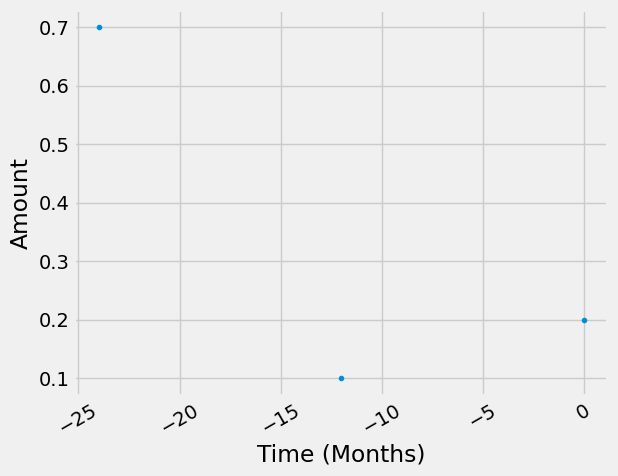

In [4]:
td_glider_production.graph(resolution="M")

Now we attach the temporal distributions to the exchanges they belong to. The helper function `add_temporal_distribution_to_exchange` from `bw_timex.utils` finds an exchange for you, based on the process it comes from (`input_...`) and the process it goes to (`output_...`). We identify the processes by their name and database here.

In [5]:
from bw_timex.utils import add_temporal_distribution_to_exchange

add_temporal_distribution_to_exchange(
    td_glider_production,
    input_name="glider",
    input_database="background_2020",
    output_name="production of an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_powertrain_and_battery_production,
    input_name="powertrain",
    input_database="background_2020",
    output_name="production of an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_powertrain_and_battery_production,
    input_name="battery",
    input_database="background_2020",
    output_name="production of an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_assembly_and_delivery,
    input_name="production of an electric vehicle",
    input_database="foreground",
    output_name="driving an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_use_phase,
    input_name="electricity",
    input_database="background_2020",
    output_name="driving an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_disassemble_used_ev,
    input_name="used electric vehicle",
    input_database="foreground",
    output_name="driving an electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_treating_waste,
    input_name="glider_eol",
    input_database="background_2020",
    output_name="used electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_treating_waste,
    input_name="powertrain_eol",
    input_database="background_2020",
    output_name="used electric vehicle",
    output_database="foreground",
)
add_temporal_distribution_to_exchange(
    td_treating_waste,
    input_name="battery_eol",
    input_database="background_2020",
    output_name="used electric vehicle",
    output_database="foreground",
)

2026-08-21 12:20:25.765 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 840 None 'glider' (None, somewhere, None) to 'production of an electric vehicle' (unit, GLO, None).


2026-08-21 12:20:25.768 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 80 None 'powertrain' (None, somewhere, None) to 'production of an electric vehicle' (unit, GLO, None).


2026-08-21 12:20:25.770 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 280 None 'battery' (None, somewhere, None) to 'production of an electric vehicle' (unit, GLO, None).


2026-08-21 12:20:25.773 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 1 unit 'production of an electric vehicle' (unit, GLO, None) to 'driving an electric vehicle' (transport over an ev lifetime, GLO, None).


2026-08-21 12:20:25.776 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: 30000.0 None 'electricity' (None, somewhere, None) to 'driving an electric vehicle' (transport over an ev lifetime, GLO, None).


2026-08-21 12:20:25.778 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: -1 unit 'used electric vehicle' (unit, GLO, None) to 'driving an electric vehicle' (transport over an ev lifetime, GLO, None).


2026-08-21 12:20:25.780 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: -840 None 'glider_eol' (None, somewhere, None) to 'used electric vehicle' (unit, GLO, None).


2026-08-21 12:20:25.783 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: -80 None 'powertrain_eol' (None, somewhere, None) to 'used electric vehicle' (unit, GLO, None).


2026-08-21 12:20:25.785 | INFO     | bw_timex.utils:add_temporal_distribution_to_exchange:670 - Added temporal distribution to exchange Exchange: -280 None 'battery_eol' (None, somewhere, None) to 'used electric vehicle' (unit, GLO, None).


## Time-explicit LCA

Besides the functional unit and the impact assessment method, `bw_timex` needs to know which point in time each background database represents. That information is recorded once, as `representative_time` metadata on each database, using `set_database_metadata`. The `foreground` holds our functional unit, so it is treated as `"dynamic"` automatically.

In [6]:
from datetime import datetime

from bw_timex import set_database_metadata

functional_unit = {driving: 1}  # transport over 1 ev lifetime

method = ("GWP", "example")

set_database_metadata("background_2020", representative_time=datetime(2020, 1, 1))
set_database_metadata("background_2030", representative_time=datetime(2030, 1, 1))
set_database_metadata("background_2040", representative_time=datetime(2040, 1, 1))

{'depends': ['biosphere'],
 'backend': 'sqlite',
 'number': 0,
 'modified': '2026-08-21T12:20:25.349453',
 'geocollections': [],
 'processed': '2026-08-21T12:20:25.391338',
 'dirty': False,
 'searchable': True,
 'representative_time': '2040-01-01T00:00:00'}

With that, we can set up a `TimexLCA`. It works like a normal `bw2calc.LCA`: `TimexLCA` reads the metadata we just set automatically, no timing argument needed:

In [7]:
from bw_timex import TimexLCA

tlca = TimexLCA(functional_unit, method)

2026-08-21 12:20:25.793 | INFO     | bw_timex.timex_lca:__init__:174 - Initializing TimexLCA object...


2026-08-21 12:20:25.794 | INFO     | bw_timex.timex_lca:__init__:194 - Calculating base LCA...


2026-08-21 12:20:25.794 | INFO     | bw_timex.timex_lca:clean_databases:1355 - Reprocessing 1 modified database(s) before calculating: foreground. This can take a while for large databases.


2026-08-21 12:20:25.799 | INFO     | bw_timex.timex_lca:clean_databases:1361 - Done reprocessing modified databases.


2026-08-21 12:20:25.808 | INFO     | bw_timex.timex_lca:__init__:211 - Collecting node infos...


2026-08-21 12:20:25.811 | INFO     | bw_timex.timex_lca:__init__:223 - Loading node metadata from 4 database(s)...


2026-08-21 12:20:25.812 | INFO     | bw_timex.timex_lca:__init__:260 - TimexLCA initialized.


First, `bw_timex` traverses the supply chain and collects when each process occurs in a timeline:

In [8]:
tlca.build_timeline(
    temporal_grouping="month",  # aggregate timeline to next month
    graph_traversal="bfs",  # breadth first traversal because foreground is relatively small
)

2026-08-21 12:20:25.814 | INFO     | bw_timex.timex_lca:build_timeline:453 - No edge filter function provided. Skipping all edges in background databases.


2026-08-21 12:20:25.815 | INFO     | bw_timex.timex_lca:build_timeline:474 - Creating activity time mapping...


2026-08-21 12:20:25.816 | INFO     | bw_timex.timeline_builder:__init__:112 - Traversing supply chain graph...


2026-08-21 12:20:25.824 | INFO     | bw_timex.timeline_builder:build_timeline:183 - Building timeline...


2026-08-21 12:20:25.841 | INFO     | bw_timex.timeline_builder:get_weights_for_interpolation_between_nearest_years:755 - Reference date 2040-09-01 00:00:00 is higher than all provided dates. Data will be taken from the closest lower year.


,date_producer,producer_name,date_consumer,consumer_name,amount,temporal_market_shares
0,2024-06-01,glider,2026-06-01,production of an electric vehicle,588.0,"{'background_2020': 0.558, 'background_2030': ..."
1,2024-07-01,glider,2026-07-01,production of an electric vehicle,588.0,"{'background_2020': 0.55, 'background_2030': 0..."
2,2025-06-01,glider,2026-06-01,production of an electric vehicle,84.0,"{'background_2020': 0.459, 'background_2030': ..."
3,2025-06-01,powertrain,2026-06-01,production of an electric vehicle,80.0,"{'background_2020': 0.459, 'background_2030': ..."
4,2025-06-01,battery,2026-06-01,production of an electric vehicle,280.0,"{'background_2020': 0.459, 'background_2030': ..."
5,2025-07-01,glider,2026-07-01,production of an electric vehicle,84.0,"{'background_2020': 0.45, 'background_2030': 0..."
6,2025-07-01,powertrain,2026-07-01,production of an electric vehicle,80.0,"{'background_2020': 0.45, 'background_2030': 0..."
7,2025-07-01,battery,2026-07-01,production of an electric vehicle,280.0,"{'background_2020': 0.45, 'background_2030': 0..."
8,2026-06-01,glider,2026-06-01,production of an electric vehicle,168.0,"{'background_2020': 0.359, 'background_2030': ..."
9,2026-06-01,production of an electric vehicle,2026-09-01,driving an electric vehicle,0.2,None


Next, we calculate the time-explicit inventory. This relinks all processes to the background databases matching their timing:

In [9]:
tlca.lci()

2026-08-21 12:20:25.855 | INFO     | bw_timex.timex_lca:lci:634 - Expanding matrices...


2026-08-21 12:20:25.869 | INFO     | bw_timex.timex_lca:lci:653 - Calculating dynamic inventory...


Now we can get the time-explicit score, using the static characterization method we chose above:

In [10]:
tlca.static_lcia()
tlca.static_score  # kg CO2-eq

15066.797664957092

For comparison, a conventional LCA with a fixed background database (here: 2020) - `bw_timex` calculated this along the way:

In [11]:
tlca.base_lca.score  # kg CO2-eq

28089.199999794364

## Dynamic characterization

Since we know *when* each emission occurs, we can also characterize them dynamically, instead of lumping everything together at one point in time. For ecoinvent biosphere flows, `bw_timex` maps the parameterized characterization functions from [`dynamic_characterization`](https://dynamic-characterization.readthedocs.io/en/latest/) (based on IPCC AR6) automatically. Our made-up biosphere flow is unknown to that package, so we map it to the CO<sub>2</sub> function ourselves:

In [12]:
from dynamic_characterization.ipcc_ar6.radiative_forcing import characterize_co2

characterization_functions = {
    bd.get_node(code="CO2").id: characterize_co2,
}

tlca.dynamic_lcia(metric="GWP", characterization_functions=characterization_functions)
tlca.dynamic_score  # kg CO2-eq (GWP100)

np.float64(15066.797664957092)

And plot how that impact is distributed over time, stacked by the processes causing it:

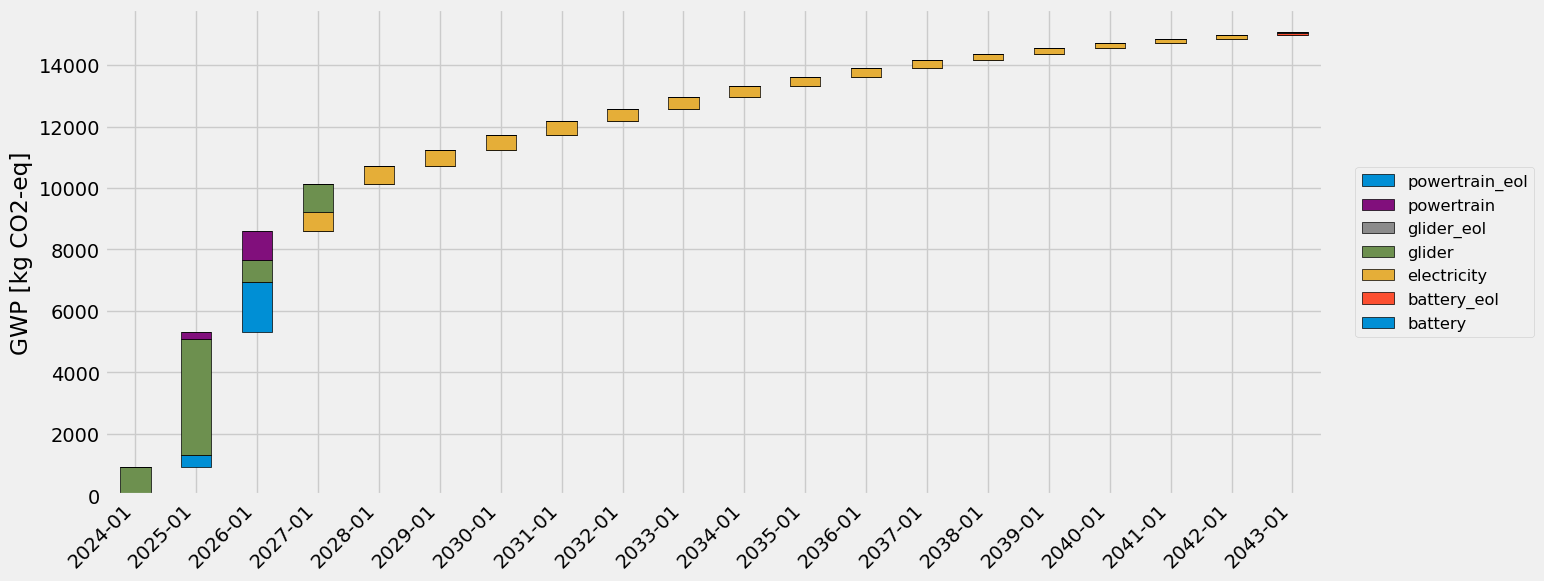

In [13]:
from bw_timex.utils import plot_characterized_inventory_as_waterfall

plot_characterized_inventory_as_waterfall(tlca)

That's it: same modelling as a normal LCA, plus temporal distributions on the exchanges, and the background databases are chosen according to when things actually happen.

If you want to dig deeper - other temporal resolutions, custom graph traversal, radiative forcing as a metric, or a comparison against fully prospective results - have a look at the [detailed version](../examples/electric_vehicle_premise_detailed.ipynb) of this example.